# AGFN Hall-of-Fame Visualizer — Tutorial

Turn a finished (or in-progress) **de novo docking** run into figures. This notebook reads the
artifacts written during training and answers three questions:

1. **How did training go?** — plot key curves from `metrics.csv`.
2. **What did it make?** — draw the top-`N` highest-**reward** molecules in 2D.
3. **How do they bind?** — show each molecule's 3D docked pose inside the target pocket
   (a port of Section 4c of `RxnFlow/notebooks/05_visualize_docking_poses.ipynb`).

**Files this notebook reads** (written by training):

| File | Where | What |
|---|---|---|
| `top100_by_reward.sdf` / `top100_by_affinity.sdf` | parent log dir | top-100 molecules + **3D docked poses** + SD tags (`reward`, `docking_score`, `iteration`, `rank`) |
| `top100_by_reward.csv` / `top100_by_affinity.csv` | parent log dir | the same hall of fame as flat tables |
| `metrics.csv`, `config.json` | run subfolder | per-step metrics; run config (target + docking box) |

The hall-of-fame `top100_*` files live in the **stable parent** log dir (cumulative across runs);
`metrics.csv`/`config.json` live in the **timestamped run subfolder**. The setup cell handles both.

> **Prerequisite:** `py3Dmol` for the 3D viewer. If missing: `pip install py3Dmol` into the
> `agfn-no-vina` env, then restart the kernel.

## Section 0 — Setup

Edit `LOG_DIR` to point at your run's **parent** log directory (the one holding the `top100_*` files, e.g. `AGFN_logs/debug_run`). `N` is how many top-reward molecules to draw/dock-view; `POCKET_DIST` is the Å cutoff for the pocket surface.

In [1]:
import os, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import HTML, display

try:
    import py3Dmol
except ImportError as e:
    raise SystemExit("py3Dmol is required: `pip install py3Dmol`, then restart the kernel.") from e

# --- knobs -------------------------------------------------------------------------------
# Parent log dir holding top100_*.sdf / .csv. Override without editing via AGFN_VIS_LOG_DIR.
LOG_DIR = Path(os.environ.get("AGFN_VIS_LOG_DIR",
                              "/home/aid/dkoh/log/generative/trash"))
REPO_ROOT = Path(os.environ.get("AGFN_REPO_ROOT", "/home/aid/dkoh/third_party/AGFN"))
N = 10                 # how many top-reward molecules to visualize
POCKET_DIST = 5.0      # Angstrom cutoff for pocket residues / surface
RANK_BY = "reward"     # "reward" or "affinity" -> which top100_by_*.sdf to read
# -----------------------------------------------------------------------------------------

assert LOG_DIR.exists(), f"LOG_DIR not found: {LOG_DIR}"

# Auto-find the latest run subfolder that has metrics.csv / config.json.
run_dirs = sorted([p for p in LOG_DIR.iterdir() if p.is_dir() and (p / "metrics.csv").exists()])
RUN_SUBDIR = run_dirs[-1] if run_dirs else LOG_DIR
metrics_csv = RUN_SUBDIR / "metrics.csv"
config_json = RUN_SUBDIR / "config.json"

# The hall of fame (top100_by_*.csv/.sdf) is written into the per-run subdir for new runs, but
# older runs wrote it into the parent LOG_DIR -- prefer the run subdir, fall back to the parent.
def _resolve_hof(name):
    cand = RUN_SUBDIR / name
    return cand if cand.exists() else LOG_DIR / name
sdf_path          = _resolve_hof(f"top100_by_{RANK_BY}.sdf")
csv_path          = _resolve_hof(f"top100_by_{RANK_BY}.csv")
reward_csv_path   = _resolve_hof("top100_by_reward.csv")    # used by the top-K curves below
affinity_csv_path = _resolve_hof("top100_by_affinity.csv")

# Resolve the receptor + docking box from the run config (paths are repo-root-relative).
receptor_path, box_center, box_size, target_name = None, None, None, None
if config_json.exists():
    cfg = json.loads(config_json.read_text())
    target_name = cfg.get("target_name")
    grid = cfg.get("target_grid", {}).get(target_name, {})
    if grid:
        rp = Path(grid["receptor"])
        receptor_path = rp if rp.is_absolute() else (REPO_ROOT / rp)
        box_center = (grid["center_x"], grid["center_y"], grid["center_z"])
        box_size = (grid["size_x"], grid["size_y"], grid["size_z"])

print(f"LOG_DIR      : {LOG_DIR}")
print(f"run subfolder: {RUN_SUBDIR.name}")
print(f"metrics.csv  : {'found' if metrics_csv.exists() else 'MISSING'}")
print(f"hall of fame : {sdf_path.name} {'found' if sdf_path.exists() else 'MISSING (run training first)'} (dir: {sdf_path.parent.name})")
print(f"target       : {target_name}   receptor: {receptor_path}")
print(f"docking box  : center={box_center} size={box_size}")

LOG_DIR      : /home/aid/dkoh/log/generative/trash
run subfolder: braf_RTB_Denovo_20260527_174606
metrics.csv  : found
hall of fame : top100_by_reward.sdf found (dir: braf_RTB_Denovo_20260527_174606)
target       : braf   receptor: /home/aid/dkoh/third_party/AGFN/data/docking/braf.pdbqt
docking box  : center=(84.194, 6.949, -7.081) size=(22.032, 19.211, 14.106)


## Section 1 — Training curves from `metrics.csv`

`metrics.csv` has one row per training step. We plot a curated subset versus `Train_iter`,
auto-skipping any column that isn't present so this works across configs. Watch
**`Percent_novel_cumulative`**: it starts near 100% and *falls* as the model rediscovers the
same molecules — the diversity signal that the per-batch `Percent_unique_in_batch` (now a true
percentage over the full sampled batch) can't show once the generator is confident.

Note: some headers carry trailing spaces (e.g. `"Total loss "`); we match by stripped name.

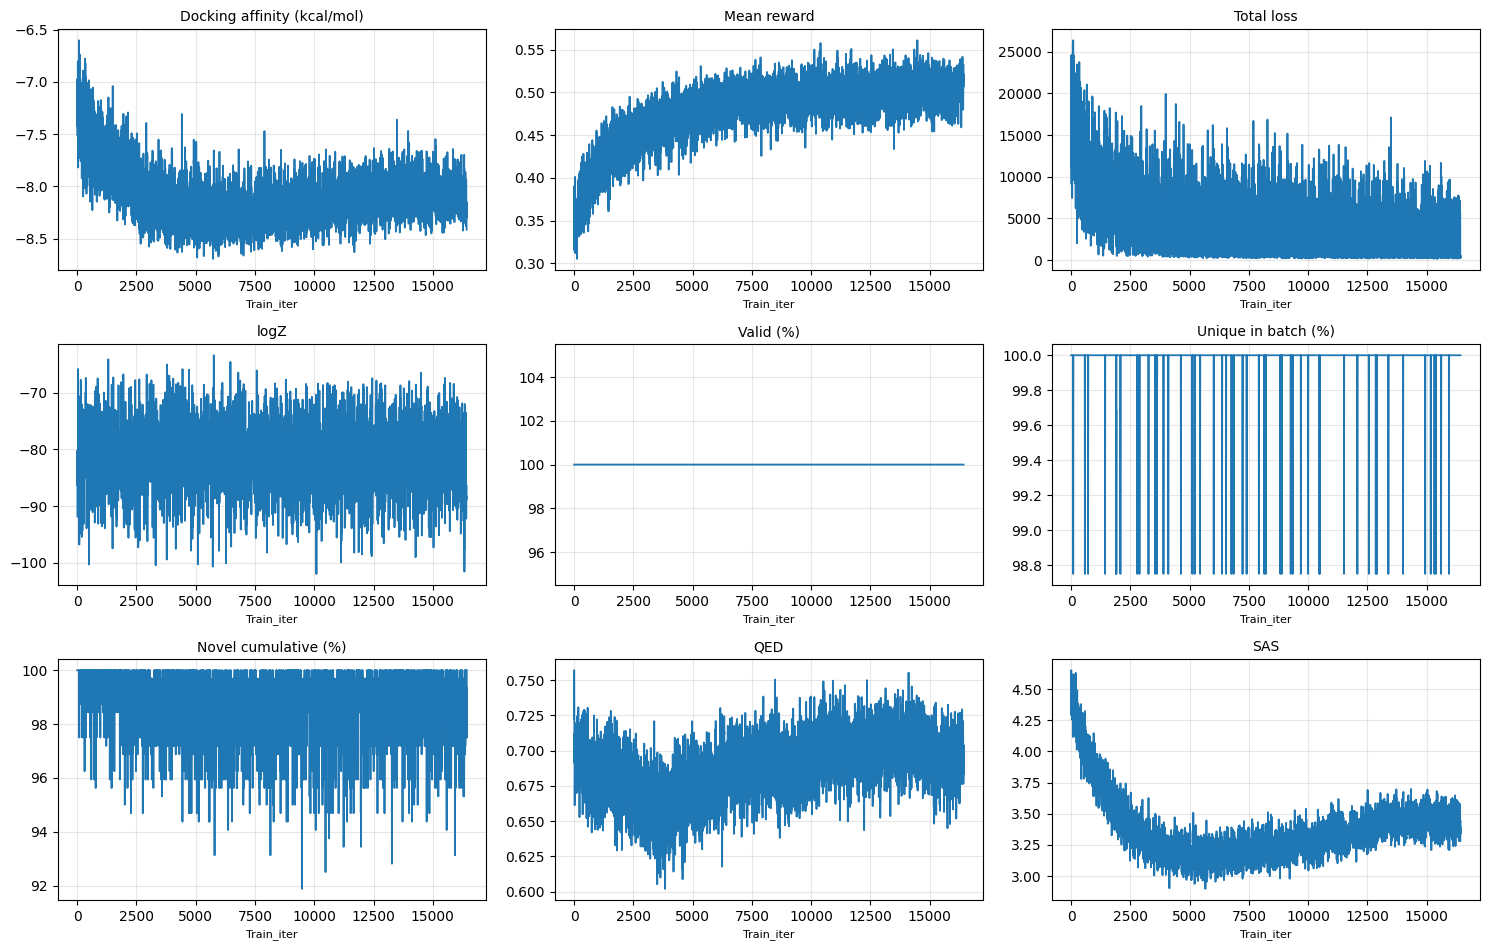

In [2]:
def plot_metrics(metrics_csv, smooth=1):
    df = pd.read_csv(metrics_csv)
    df.columns = [c.strip() for c in df.columns]          # normalize trailing spaces
    xcol = "Train_iter" if "Train_iter" in df.columns else df.columns[-1]

    # (column, axis-title) pairs; missing columns are skipped automatically.
    wanted = [
        ("Average QedxSaxDock score online", "Docking affinity (kcal/mol)"),
        ("Average Overall Reward",           "Mean reward"),
        ("Total loss",                       "Total loss"),
        ("logZ",                             "logZ"),
        ("Percent_valid_mols",               "Valid (%)"),
        ("Percent_unique_in_batch",          "Unique in batch (%)"),
        ("Percent_novel_cumulative",         "Novel cumulative (%)"),
        ("Avg. QED onln",                    "QED"),
        ("Avg. SAS onln",                    "SAS"),
    ]
    present = [(c, t) for c, t in wanted if c in df.columns]
    ncol = 3
    nrow = (len(present) + ncol - 1) // ncol
    fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.2 * nrow), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, (col, title) in zip(axes.flat, present):
        ax.axis("on")
        y = df[col].rolling(smooth, min_periods=1).mean() if smooth > 1 else df[col]
        ax.plot(df[xcol], y, lw=1.3)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel(xcol, fontsize=8)
        ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
    return df

if metrics_csv.exists():
    metrics_df = plot_metrics(metrics_csv, smooth=5)
else:
    print("metrics.csv not found — run training first.")

### Hall-of-fame curves — top-10 / top-100 mean reward & docking score

These track the **running** top-10 / top-100 generated molecules over training, so they improve
(near-)monotonically: reward goes **up**, docking score goes **down** (more negative kcal/mol =
better binding). The hall of fame only ever swaps a molecule out for a better one, so its averages
can't regress.

- If the run logged the true `Top-10/Top-100 mean reward|docking score` columns (added to
  `metrics.csv` during training), we plot those directly vs `Train_iter`.
- Otherwise we **reconstruct** an approximate curve from the final `top100_by_*.csv` using each
  molecule's discovery `iteration`. This uses only the final survivors (hindsight), so the top-10
  line is a clean lower bound while the top-100 line is a running mean until 100 molecules exist.

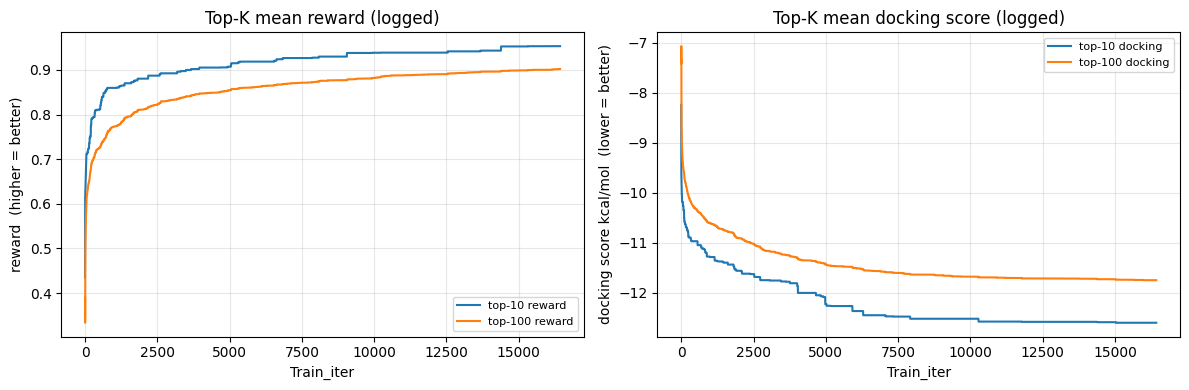

In [3]:
def topk_curves_from_metrics(df):
    """True curves logged during training (if the run wrote them). Returns (x, {label: series}) or None."""
    cols = {
        "top-10 reward":   "Top-10 mean reward",
        "top-100 reward":  "Top-100 mean reward",
        "top-10 docking":  "Top-10 mean docking score",
        "top-100 docking": "Top-100 mean docking score",
    }
    if not any(c in df.columns for c in cols.values()):
        return None
    x = df["Train_iter"] if "Train_iter" in df.columns else df.index
    return x, {k: df[v] for k, v in cols.items() if v in df.columns}


def topk_curves_reconstructed(reward_csv, affinity_csv, ks=(10, 100)):
    """Approximate running top-K averages from the FINAL hall-of-fame CSVs (each row carries the
    discovery `iteration`). For each iteration t, average the best-K-so-far among final survivors.
    Caveat: survivors only (hindsight); the top-100 line is a running mean until 100 are found."""
    def _curve(path, col, best):
        if not Path(path).exists():
            return None
        d = pd.read_csv(path).dropna(subset=[col, "iteration"]).sort_values("iteration")
        if d.empty:
            return None
        rows = []
        for t in sorted(d["iteration"].unique()):
            seen = d.loc[d["iteration"] <= t, col]
            for k in ks:
                topk = seen.nlargest(k) if best == "max" else seen.nsmallest(k)
                rows.append((t, k, topk.mean()))
        return pd.DataFrame(rows, columns=["iteration", "k", "mean"])
    return {
        "reward":  _curve(reward_csv,   "reward",   "max"),   # higher reward = better
        "docking": _curve(affinity_csv, "affinity", "min"),   # lower (more negative) = better
    }


def plot_topk_curves():
    fig, (axr, axd) = plt.subplots(1, 2, figsize=(12, 4))
    logged = None
    if metrics_csv.exists():
        df = pd.read_csv(metrics_csv); df.columns = [c.strip() for c in df.columns]
        logged = topk_curves_from_metrics(df)

    if logged is not None:                                   # true curves logged during training
        x, series = logged
        for label, y in series.items():
            (axr if "reward" in label else axd).plot(x, y, lw=1.5, label=label)
        axr.set_title("Top-K mean reward (logged)")
        axd.set_title("Top-K mean docking score (logged)")
        for ax in (axr, axd):
            ax.set_xlabel("Train_iter")
    else:                                                    # reconstruct from final CSVs
        rec = topk_curves_reconstructed(reward_csv_path, affinity_csv_path)
        for col, ax, title in (("reward",  axr, "Top-K mean reward (reconstructed)"),
                               ("docking", axd, "Top-K mean docking score (reconstructed)")):
            cur = rec.get(col)
            if cur is None:
                ax.text(0.5, 0.5, f"no {col} data", ha="center", va="center"); continue
            for k, g in cur.groupby("k"):
                ax.plot(g["iteration"], g["mean"], lw=1.5, marker=".", ms=3, label=f"top-{k}")
            ax.set_title(title); ax.set_xlabel("discovery iteration")

    axr.set_ylabel("reward  (higher = better)"); axr.grid(alpha=0.3); axr.legend(fontsize=8)
    axd.set_ylabel("docking score kcal/mol  (lower = better)"); axd.grid(alpha=0.3); axd.legend(fontsize=8)
    fig.tight_layout(); plt.show()

plot_topk_curves()

## Section 2 — Top-`N` highest-reward molecules (2D)

We read `top100_by_reward.sdf` (poses + SD tags), take the first `N`, and draw clean 2D
depictions (rebuilt from each record's `smiles` tag), captioned with reward and docking score.

loaded 10 molecules from top100_by_reward.sdf


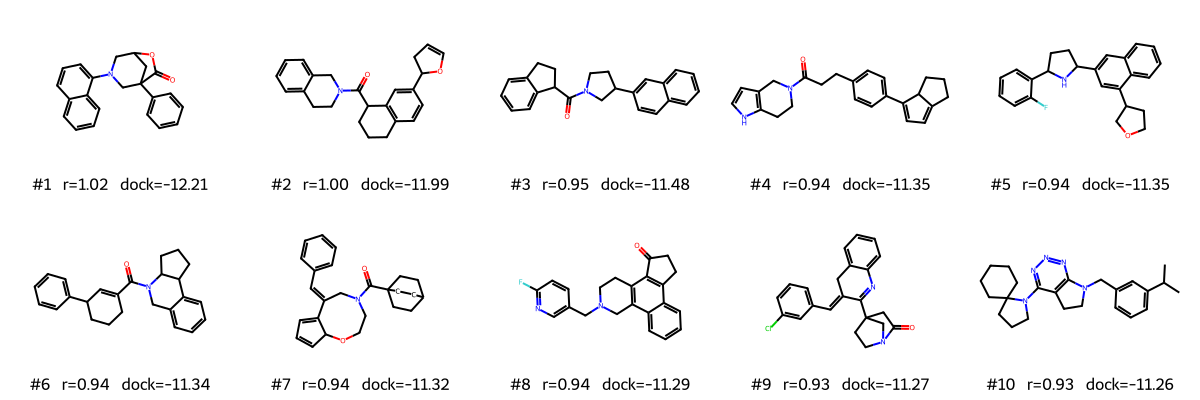

,rank,smiles,reward,affinity,iteration
0,1,O=C1O[C]2CN(c3cccc4ccccc34)CC1(c1ccccc1)C2,1.018727,-12.206,14384
1,2,O=C(C1CCCc2ccc(C3CC=CO3)cc21)N1CCc2ccccc2C1,0.999000,-11.989,9055
2,3,O=C(C1CCc2ccccc21)N1CCC(c2ccc3ccccc3c2)C1,0.953000,-11.483,12539
3,4,O=C(CCc1ccc(C2=CC=C3CCCC32)cc1)N1CCc2[nH]ccc2C1,0.940727,-11.348,13674
4,5,Fc1ccccc1C1CCC(c2cc(C3CCOC3)c3ccccc3c2)N1,0.940455,-11.345,6620
5,6,O=C(C1=CC(c2ccccc2)CCC1)N1Cc2ccccc2C2CCCC21,0.940364,-11.344,8083
6,7,O=C(N1CCOC2C=CC=C2C(=Cc2ccccc2)C1)C12CCC(CC1)CC2,0.937909,-11.317,5045
7,8,O=C1CCc2c1c1c(c3ccccc23)CN(Cc2ccc(F)nc2)CC1,0.935727,-11.293,6838
8,9,O=C1CC2(C3=Nc4ccccc4CC3=Cc3cccc(Cl)c3)CCN1C2,0.933727,-11.271,2183
9,10,CC(C)c1cccc(CN2CCc3c2nnnc3N2CCCC23CCCCC3)c1,0.932545,-11.258,16131


In [4]:
def load_hall_of_fame(sdf_path, n=None):
    """Return a list of (mol_with_3D_pose, props_dict), in file (rank) order."""
    if not Path(sdf_path).exists():
        return []
    out = []
    for m in Chem.SDMolSupplier(str(sdf_path), removeHs=False, sanitize=True):
        if m is None:
            continue
        props = {k: m.GetProp(k) for k in m.GetPropNames()}
        out.append((m, props))
        if n is not None and len(out) >= n:
            break
    return out

hof = load_hall_of_fame(sdf_path, n=N)
print(f"loaded {len(hof)} molecules from {sdf_path.name}")

if hof:
    mols2d, legends = [], []
    for m, p in hof:
        m2d = Chem.MolFromSmiles(p.get("smiles", Chem.MolToSmiles(m)))
        if m2d is None:
            continue
        AllChem.Compute2DCoords(m2d)
        mols2d.append(m2d)
        legends.append(f"#{p.get('rank','?')}  r={float(p.get('reward','nan')):.2f}  "
                       f"dock={float(p.get('docking_score','nan')):.2f}")
    img = Draw.MolsToGridImage(mols2d, legends=legends, molsPerRow=5,
                               subImgSize=(240, 200), useSVG=False)
    display(img)

    # tabular view (prefer the flat CSV when present)
    if csv_path.exists():
        display(pd.read_csv(csv_path).head(N))
    else:
        display(pd.DataFrame([
            {"rank": p.get("rank"), "reward": p.get("reward"),
             "docking_score": p.get("docking_score"), "iteration": p.get("iteration"),
             "smiles": p.get("smiles")} for _, p in hof]))
else:
    print("No SDF yet — run training to produce the hall of fame.")

## Section 3 — 3D docked pose in the target pocket

A `py3Dmol` grid, **one molecule per cell**: the protein as a gray cartoon, the ligand as
colored sticks, and a translucent **pocket surface** over residues within `POCKET_DIST` Å of
that molecule's pose.

**Why this just works (coordinate frames).** The SDF stores the *ligand only*, but Uni-Dock
writes its atoms at **absolute coordinates in the receptor's frame**. So loading the receptor and
the ligand into the same scene places the ligand in the pocket with no alignment step.

**Two AGFN adaptations** vs RxnFlow's PDB-based notebook:
1. AGFN's `.pdbqt` receptor has a **blank chain column**, so pocket selections use `resi` only.
2. A tiny `pdbqt_to_pdb_text()` converts the receptor to minimal PDB so 3Dmol renders a clean
   cartoon. Pocket residues are resolved **in Python** (not via a fragile 3Dmol `within`
   selector), exactly as RxnFlow does.

In [5]:
def pdbqt_to_pdb_text(path):
    """Minimal pdbqt -> pdb text: keep PDB columns [:66] of ATOM/HETATM, append an element guess."""
    lines = []
    for ln in open(path):
        if ln.startswith(("ATOM", "HETATM")):
            atom = ln[12:16].strip()
            elem = (atom[0] if atom else "C").upper()
            lines.append(ln[:66].rstrip("\n").ljust(66) + "          " + f"{elem:>2}" + "\n")
    lines.append("END\n")
    return "".join(lines)

# Pre-parse protein heavy-atom coordinates + residue ids from the pdbqt (for pocket selection).
PROTEIN_PDB_TEXT, PROTEIN_XYZ, PROTEIN_RESI = None, np.empty((0, 3)), []
if receptor_path and Path(receptor_path).exists():
    PROTEIN_PDB_TEXT = pdbqt_to_pdb_text(receptor_path)
    _xyz, _resi = [], []
    for ln in open(receptor_path):
        if ln.startswith(("ATOM", "HETATM")):
            try:
                _xyz.append((float(ln[30:38]), float(ln[38:46]), float(ln[46:54])))
                _resi.append(int(ln[22:26]))
            except ValueError:
                continue
    PROTEIN_XYZ, PROTEIN_RESI = np.asarray(_xyz), _resi

def _conf_xyz(mol):
    c = mol.GetConformer()
    return np.asarray([[c.GetAtomPosition(i).x, c.GetAtomPosition(i).y, c.GetAtomPosition(i).z]
                       for i in range(mol.GetNumAtoms())])

def pocket_residue_sel(mol, cutoff=POCKET_DIST):
    """3Dmol selection {model, resi:[...]} for residues with any atom within cutoff of the ligand."""
    if PROTEIN_XYZ.shape[0] == 0:
        return {"model": 0, "resi": []}
    lig = _conf_xyz(mol)
    min_d2 = ((PROTEIN_XYZ[:, None, :] - lig[None, :, :]) ** 2).sum(-1).min(axis=1)
    resis = sorted({PROTEIN_RESI[i] for i in np.where(min_d2 <= cutoff * cutoff)[0]})
    return {"model": 0, "resi": resis}

def render_pose_grid(hof, mols_per_row=2, cell_w=360, cell_h=320, surface_opacity=0.45):
    n = len(hof)
    rows = (n + mols_per_row - 1) // mols_per_row
    grid = py3Dmol.view(viewergrid=(rows, mols_per_row),
                        width=cell_w * mols_per_row, height=cell_h * rows)
    for k, (mol, props) in enumerate(hof):
        r, c = divmod(k, mols_per_row)
        if PROTEIN_PDB_TEXT is not None:
            grid.addModel(PROTEIN_PDB_TEXT, "pdb", viewer=(r, c))
            grid.setStyle({"model": 0}, {"cartoon": {"color": "lightgray", "opacity": 0.7}},
                          viewer=(r, c))
        grid.addModel(Chem.MolToMolBlock(mol), "mol", viewer=(r, c))
        grid.setStyle({"model": -1}, {"stick": {"colorscheme": "cyanCarbon", "radius": 0.2}},
                      viewer=(r, c))
        if PROTEIN_PDB_TEXT is not None:
            sel = pocket_residue_sel(mol)
            if sel["resi"]:
                grid.setStyle(sel, {"cartoon": {"color": "lightblue", "opacity": 0.5}}, viewer=(r, c))
                grid.addSurface(py3Dmol.MS, {"opacity": surface_opacity, "color": "lightblue"},
                                sel, viewer=(r, c))
        grid.addLabel(f"#{props.get('rank','?')}  dock={props.get('docking_score','?')}",
                      {"fontSize": 10, "backgroundColor": "black", "backgroundOpacity": 0.5,
                       "fontColor": "white"}, {"model": -1}, viewer=(r, c))
        grid.zoomTo({"model": -1}, viewer=(r, c))
        grid.zoom(0.8, viewer=(r, c))
    return grid

if hof and PROTEIN_PDB_TEXT is not None:
    render_pose_grid(hof[:N], mols_per_row=2).show()
elif not hof:
    print("No SDF yet — run training to produce the hall of fame.")
else:
    print(f"Receptor not found at {receptor_path}; showing ligands only is skipped.")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Section 4 — A-GFN molecular composition steps

A-GFN builds each molecule **incrementally**: a trajectory of graph-edit actions (add atom, add
bond, set charge, …) ending in a *Stop*. Here we re-load the trained model, sample a fresh batch,
**rank it by reward**, and render the step-by-step construction of the best molecule — a faithful
GFlowNet trajectory of a high-reward molecule.

> ⚠️ **Live model.** Unlike the sections above (which only read saved artifacts), this loads the
> trained checkpoint and runs **Uni-Dock docking** on the sampled batch to score/rank it — so it
> needs a **GPU** and the docking backend. Trajectories are stochastic and aren't persisted, so
> this won't reproduce a *specific* saved hall-of-fame SMILES; it shows a top molecule from a
> fresh sample. Set `RANK_INDEX` (0 = best) to walk down the fresh top-K, or
> `AGFN_VIS_CHECKPOINT` / `AGFN_VIS_N_SAMPLES` to override the checkpoint / batch size.

In [6]:
import sys, yaml
from easydict import EasyDict

# --- knobs -------------------------------------------------------------------------------
N_SAMPLES  = int(os.environ.get("AGFN_VIS_N_SAMPLES", "32"))   # trajectories to draw, then rank
RANK_INDEX = 0                                                 # 0 = best; pick within the fresh top-K
DEVICE_ID  = 0
# Default checkpoint = newest model_state_*.pt in the run subdir (the FINE-TUNED weights),
# overridable via AGFN_VIS_CHECKPOINT; falls back to hps.saved_model_path (the pretrained base).
_ckpts = sorted(RUN_SUBDIR.glob("model_state_*.pt"), key=lambda p: p.stat().st_mtime)
CHECKPOINT = os.environ.get("AGFN_VIS_CHECKPOINT") or (str(_ckpts[-1]) if _ckpts else None)
# -----------------------------------------------------------------------------------------

# Make repo imports resolve exactly as they do for denovo_driver.py.
os.chdir(REPO_ROOT)
for p in ("src", "src/apps/docking", "src/apps/docking/denovo"):
    full = str((REPO_ROOT / p).resolve())
    if full not in sys.path:
        sys.path.insert(0, full)
import torch
import torch.nn as nn

# Our checkpoints pickle an EasyDict in 'hps'. torch>=2.6 defaults torch.load(weights_only=True),
# which refuses custom classes; we trust our own checkpoints, so allowlist EasyDict for the load
# that happens inside DockingFineTuner (FineTunerRTB.__init__).
torch.serialization.add_safe_globals([EasyDict])

# hps + conditional ranges for the QedxSaxDock denovo task (same literals as denovo_driver.py).
with open(REPO_ROOT / "src/config/denovo.yml") as f:
    hps = EasyDict(yaml.safe_load(f)).finetuning
hps.update({"Z_learning_rate": 1e-3})
conditional_range_dict = {
    "tpsa":      [[10, 200], [10, 200], 0],
    "num_rings": [[1, 5],   [1, 5],   1],
    "sas":       [[1, 5],   [1, 5],   0],
    "qed":       [[0.5, 1], [0, 1],   0],
}
cond_prop_var = {"tpsa": 20, "num_rings": 1, "sas": 1, "qed": 1}
hps.task_conditionals = False
hps.task_rewards_only = False
hps.update(conditional_range_dict)
if CHECKPOINT is not None:
    hps.saved_model_path = CHECKPOINT
gfn_samples_path = f"{hps.gfn_samples_path}/GFN_gen_samples_{hps.target_name}/"
os.makedirs(gfn_samples_path, exist_ok=True)
print("checkpoint:", CHECKPOINT)

# Reuses the exact training constructor, so architecture + checkpoint loading match.
# A fine-tuned checkpoint is saved from the *pruned* (forward-only) model, so it lacks the full
# model's backward-policy heads (mlps.remove_node/remove_edge*). FineTunerRTB builds the full model
# and load_state_dict's strictly -> that would error on the missing P_B heads. We load leniently:
# those heads are immediately pruned away (and never used for forward sampling), so this matches
# training's inference path exactly. Restored right after so nothing else is affected.
from denovo_trainer import DockingFineTuner
_orig_lsd = nn.Module.load_state_dict
nn.Module.load_state_dict = lambda self, sd, strict=True, **kw: _orig_lsd(self, sd, strict=False, **kw)
try:
    finetuner = DockingFineTuner(
        hps, conditional_range_dict, cond_prop_var,
        CHECKPOINT, rank=DEVICE_ID, world_size=1, gfn_samples_path=gfn_samples_path,
    )
finally:
    nn.Module.load_state_dict = _orig_lsd
finetuner.gfn_trainer.model.train(False)
print("loaded model on", finetuner.device)

checkpoint: /home/aid/dkoh/log/generative/trash/braf_RTB_Denovo_20260527_174606/model_state_braf_RTB_Denovo_20260527_174606_16400.pt
molbuildingenv.py c import error
_IncompatibleKeys(missing_keys=['mlps.remove_node.0.weight', 'mlps.remove_node.0.bias', 'mlps.remove_node.2.weight', 'mlps.remove_node.2.bias', 'mlps.remove_node.4.weight', 'mlps.remove_node.4.bias', 'mlps.remove_node.6.weight', 'mlps.remove_node.6.bias', 'mlps.remove_node.8.weight', 'mlps.remove_node.8.bias', 'mlps.remove_node.10.weight', 'mlps.remove_node.10.bias', 'mlps.remove_node.12.weight', 'mlps.remove_node.12.bias', 'mlps.remove_node.14.weight', 'mlps.remove_node.14.bias', 'mlps.remove_node.16.weight', 'mlps.remove_node.16.bias', 'mlps.remove_node.18.weight', 'mlps.remove_node.18.bias', 'mlps.remove_node.20.weight', 'mlps.remove_node.20.bias', 'mlps.remove_node_attr.0.weight', 'mlps.remove_node_attr.0.bias', 'mlps.remove_node_attr.2.weight', 'mlps.remove_node_attr.2.bias', 'mlps.remove_node_attr.4.weight', 'mlps.re

In [9]:
order

array([17, 10, 15, 30, 11, 13, 26, 29,  3,  9, 14, 20, 28, 16, 23, 22, 24,
       21, 27, 25, 12,  8,  0,  2, 31, 19,  4,  5, 18,  6,  7,  1])

sampled 32 trajectories, 32 valid+renderable


[09:18:35] DEPRECATION WARNING: please use MorganGenerator
[09:18:35] DEPRECATION WARNING: please use MorganGenerator
[09:18:35] DEPRECATION WARNING: please use MorganGenerator
[09:18:35] DEPRECATION WARNING: please use MorganGenerator
[09:18:35] DEPRECATION WARNING: please use MorganGenerator
[09:18:35] DEPRECATION WARNING: please use MorganGenerator
[09:18:35] DEPRECATION WARNING: please use MorganGenerator
[09:18:35] DEPRECATION WARNING: please use MorganGenerator
[09:18:35] DEPRECATION WARNING: please use MorganGenerator
[09:18:35] DEPRECATION WARNING: please use MorganGenerator
[09:18:35] DEPRECATION WARNING: please use MorganGenerator
[09:18:35] DEPRECATION WARNING: please use MorganGenerator
[09:18:35] DEPRECATION WARNING: please use MorganGenerator
[09:18:35] DEPRECATION WARNING: please use MorganGenerator
[09:18:35] DEPRECATION WARNING: please use MorganGenerator
[09:18:35] DEPRECATION WARNING: please use MorganGenerator
[09:18:35] DEPRECATION WARNING: please use MorganGenerat

[INFO][2026-05-28 09:18:35,950][unidock.py 94] unidock cmd: unidock --receptor data/docking/braf.pdbqt --ligand_index unidock_20260528091835/ligand_index_mdwy.txt --dir /tmp/tmpy1d8ti97/workdir/docking_dir/docking_results --search_mode fast --center_x 84.194 --center_y 6.949 --center_z -7.081 --size_x 22.032 --size_y 19.211 --size_z 14.106 --scoring vina --num_modes 1 --energy_range 3.0 --refine_step 3 --seed 1 --verbosity 2 --keep_nonpolar_H
UNIDOCK AFFINITIES: mean=-8.063, std=0.796, min=-9.659, max=-6.373
selected fresh rank #0:  reward=+0.690  docking=-8.59 kcal/mol
  SMILES: O=C(c1ccc(F)cc1)N1CC2CCCC(C1)C2C(=O)N1Cc2nc[nH]c2C1
40 renderable composition steps (t=0 -> final)


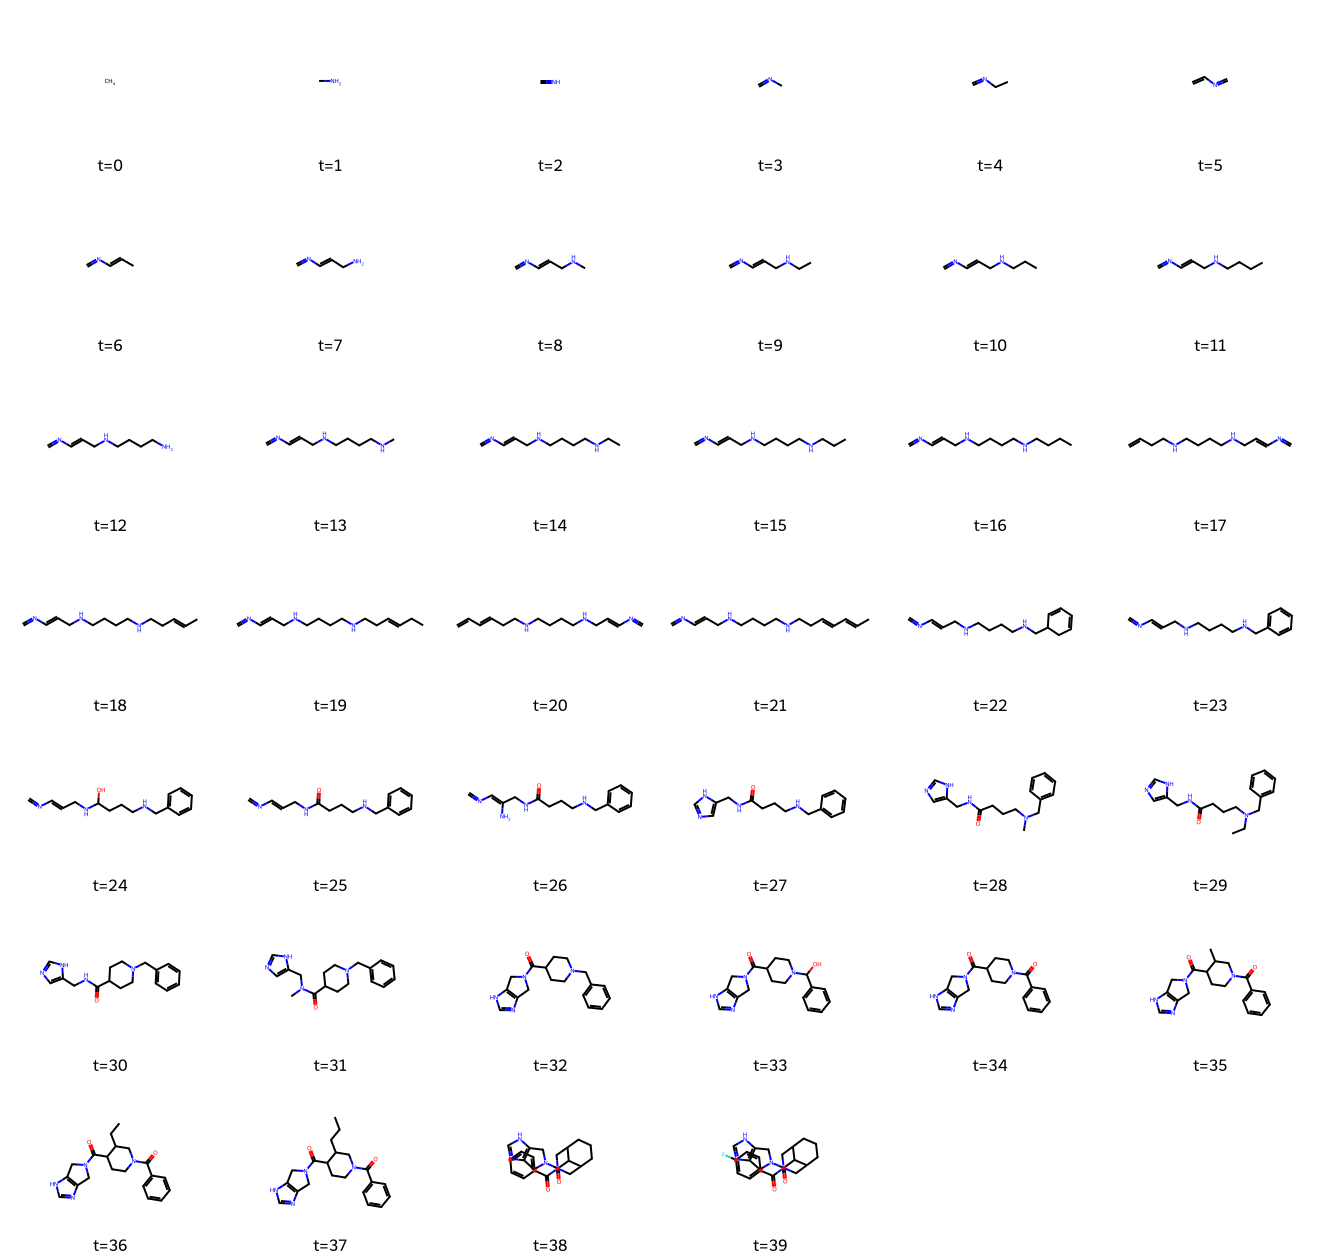

Final molecule:


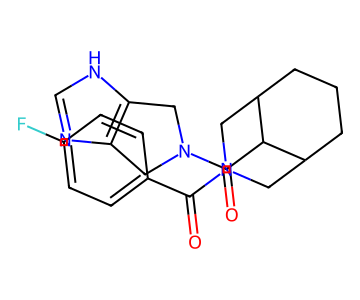

In [7]:
# Sample a fresh batch, rank by reward (replicates samp_iter_finetune.py), and render the best
# molecule's build steps. Ranking calls the same reward pipeline -> this DOCKS the batch.
ci = finetuner.cond_info_task
cond_info_enc = ci.thermometer_encoding(ci.compute_cond_info_forward(N_SAMPLES)).to(finetuner.device)
with torch.no_grad():
    trajs = finetuner.graph_sampler.sample_from_model(
        finetuner.gfn_trainer.model, N_SAMPLES, cond_info_enc, finetuner.device,
        random_stop_action_prob=0.0, random_action_prob=0.0, seed_graph=None,
    )

# keep valid trajectories whose final graph yields a molecule
valid, mols = [], []
for t in trajs:
    if not t["is_valid"]:
        continue
    try:
        m = finetuner.ctx.graph_to_mol(t["traj"][-1][0])
    except Exception:
        m = None
    if m is not None:
        valid.append(t); mols.append(m)
print(f"sampled {len(trajs)} trajectories, {len(valid)} valid+renderable")

# reward = molecular reward * normalized docking reward; true_task_score = docking affinity
rew = np.asarray(finetuner.reward.molecular_rewards(mols)[2]).reshape(-1)
normalized_task_rew, true_task_score = finetuner.reward.task_reward(hps.task, mols)
flat = rew * np.asarray(normalized_task_rew).reshape(-1)
affinity = np.asarray(true_task_score).reshape(-1)

order = np.argsort(-flat)                         # best reward first -> the fresh "top-K"
sel = int(order[min(RANK_INDEX, len(order) - 1)])
print(f"selected fresh rank #{RANK_INDEX}:  reward={flat[sel]:+.3f}  docking={affinity[sel]:+.2f} kcal/mol")
print(f"  SMILES: {Chem.MolToSmiles(mols[sel])}")

# Composition steps: traj[k][0] is the pre-action graph at step k (no env.step replay needed).
steps = []
for g, _action in valid[sel]["traj"]:
    if len(g.nodes) == 0:
        continue
    try:
        m = finetuner.ctx.graph_to_mol(g)
    except Exception:
        m = None
    if m is not None:
        steps.append(m)
print(f"{len(steps)} renderable composition steps (t=0 -> final)")
display(Draw.MolsToGridImage(steps, molsPerRow=6, subImgSize=(220, 180),
                             legends=[f"t={i}" for i in range(len(steps))]))
print("Final molecule:")
display(Draw.MolToImage(mols[sel], size=(360, 300)))

## What's next

- Flip `RANK_BY = "affinity"` in Section 0 to inspect the best docking scores instead of rewards.
- Increase `N` to view more molecules (the SDF holds 100).
- For interaction fingerprints (H-bonds, π-stacking, …), feed a pose + the receptor PDB to PLIP,
  as in RxnFlow's Section 5 — out of scope here.

In [14]:
Chem.MolToSmiles(mols[17])

'O=C(c1ccc(F)cc1)N1CC2CCCC(C1)C2C(=O)N1Cc2nc[nH]c2C1'

In [13]:
# mol = Chem.MolFromSmiles(your_smiles)  # or however you loaded it
for atom in mols[17].GetAtoms():
    n_rad = atom.GetNumRadicalElectrons()
    print(n_rad)
    if n_rad:
        print(atom.GetIdx(), atom.GetSymbol(), "radicals:", n_rad)

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [29]:
from rdkit.Chem import AllChem, Draw

AllChem.Compute2DCoords(mols[5])              # default
# or with the CoordGen algorithm (usually nicer for complex/fused rings):
from rdkit.Chem import rdCoordGen
rdCoordGen.AddCoords(mols[5])

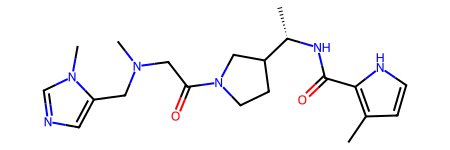

In [31]:
mols[6]

In [23]:
len(mols)

32